In [ ]:
# STEP 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Text Processing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Train-Test Split
from sklearn.model_selection import train_test_split

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# STEP 2: Load Dataset
df = pd.read_csv("spam.csv", encoding="latin-1")

print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nDataset Info:")
print(df.info())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Dataset Shape:
(5572, 5)

Column Names:
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   

In [ ]:

# STEP 3: Clean Dataset Columns

df = df[['v1', 'v2']]
df.columns = ['label', 'message']
print(df.head())

print("\nColumns:")
print(df.columns)

print("\nShape:")
print(df.shape)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Columns:
Index(['label', 'message'], dtype='object')

Shape:
(5572, 2)


In [ ]:

# STEP 4: Check Missing Values
print("Missing values:")
print(df.isnull().sum())

# Check Duplicate Messages
print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
label      0
message    0
dtype: int64

Duplicate rows:
403


In [ ]:

# STEP 5: Check Class Distribution
print("Number of messages in each class:")
print(df['label'].value_counts())

# Percentage of each class
print("\nPercentage of each class:")
print(df['label'].value_counts(normalize=True) * 100)

Number of messages in each class:
label
ham     4825
spam     747
Name: count, dtype: int64

Percentage of each class:
label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [ ]:
# STEP 6: Remove Duplicate Rows
print("Shape before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

# Convert Labels into 0 and 1
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})
print("\nLabels after conversion:")
print(df['label'].value_counts())

Shape before removing duplicates: (5572, 2)
Shape after removing duplicates: (5169, 2)

Labels after conversion:
label
0    4516
1     653
Name: count, dtype: int64


In [ ]:

# STEP 7: Separate Input and Output
X = df['message']
y = df['label']

print("Input (X):")
print(X.head())

print("\nOutput (y):")
print(y.head())

print("\nShapes:")
print("X shape:", X.shape)
print("y shape:", y.shape)

Input (X):
0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: object

Output (y):
0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64

Shapes:
X shape: (5169,)
y shape: (5169,)


In [ ]:
# STEP 8: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.20,random_state=42,stratify=y)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training samples: 4135
Testing samples: 1034

Training data shape: (4135,)
Testing data shape: (1034,)


In [ ]:
# STEP 9: Text Tokenization
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

print("Total unique words:", len(tokenizer.word_index))
print("\nFirst 20 words:")
print(list(tokenizer.word_index.items())[:20])

Total unique words: 7816

First 20 words:
[('<OOV>', 1), ('i', 2), ('to', 3), ('you', 4), ('a', 5), ('the', 6), ('u', 7), ('and', 8), ('in', 9), ('is', 10), ('me', 11), ('for', 12), ('my', 13), ('your', 14), ('it', 15), ('of', 16), ('have', 17), ('2', 18), ('that', 19), ('call', 20)]


In [ ]:
# STEP 10: Convert Text to Sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Original message:")
print(X_train.iloc[0])

print("\nConverted sequence:")
print(X_train_seq[0])

Original message:
Cool. So how come you havent been wined and dined before?

Converted sequence:
[282, 24, 45, 61, 4, 470, 108, 3488, 8, 3489, 181]


In [ ]:
# STEP 11: Padding
MAX_LEN = 100
X_train_pad = pad_sequences(X_train_seq,maxlen=MAX_LEN,padding='post',truncating='post')

X_test_pad = pad_sequences(X_test_seq,maxlen=MAX_LEN,padding='post',truncating='post')

print("X_train shape:", X_train_pad.shape)
print("X_test shape:", X_test_pad.shape)

print("\nFirst padded sequence:")
print(X_train_pad[0])

X_train shape: (4135, 100)
X_test shape: (1034, 100)

First padded sequence:
[ 282   24   45   61    4  470  108 3488    8 3489  181    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [ ]:
# STEP 12: Build Deep Learning Model
model = Sequential()

model.add(Embedding(input_dim=5000,output_dim=64,input_length=MAX_LEN ))

model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 13: Compile the Model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
# STEP 14: Train the Model
from tensorflow.keras.callbacks import EarlyStopping

# Early Stopping
early_stop = EarlyStopping( monitor='val_loss',patience=3,restore_best_weights=True)

# Train the model
history = model.fit(X_train_pad,y_train,epochs=30,batch_size=32,validation_split=0.2,callbacks=[early_stop])

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8652 - loss: 0.4082 - val_accuracy: 0.8791 - val_loss: 0.3726
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8724 - loss: 0.3869 - val_accuracy: 0.8791 - val_loss: 0.3716
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.8724 - loss: 0.3873 - val_accuracy: 0.8791 - val_loss: 0.3729
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8724 - loss: 0.3897 - val_accuracy: 0.8791 - val_loss: 0.3689
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.8724 - loss: 0.3852 - val_accuracy: 0.8791 - val_loss: 0.3690
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.8724 - loss: 0.3870 - val_accuracy: 0.8791 - val_loss: 0.3700
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8724 - loss: 0.3831 - val_accuracy: 0.8791 - val_loss: 0.3688
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8724 - loss: 0.3844 - val_accu

In [ ]:
# STEP 15: Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test_pad,y_test,verbose=1)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8733 - loss: 0.3804

Test Loss: 0.3803728520870209
Test Accuracy: 0.8733075261116028
Test Accuracy (%): 87.33075261116028


In [ ]:
# STEP 16: Predictions

y_pred_prob = model.predict(X_test_pad)

y_pred = (y_pred_prob >= 0.5).astype(int)

print("First 10 predicted probabilities:")
print(y_pred_prob[:10])

print("\nFirst 10 predicted classes:")
print(y_pred[:10].flatten())

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
First 10 predicted probabilities:
[[0.12103886]
 [0.12103886]
 [0.12103886]
 [0.12103886]
 [0.12103886]
 [0.12103886]
 [0.12103886]
 [0.12103886]
 [0.12103886]
 [0.12103886]]

First 10 predicted classes:
[0 0 0 0 0 0 0 0 0 0]


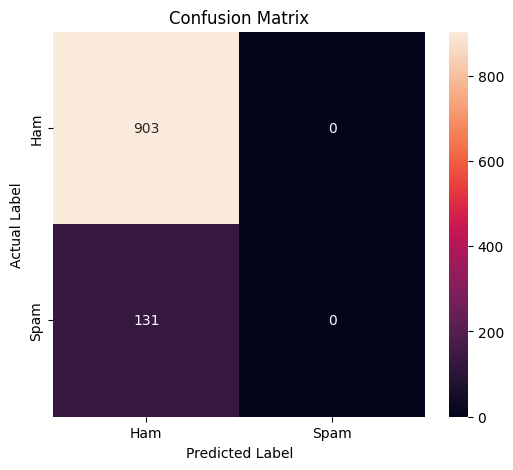

In [ ]:
# STEP 17: Plot Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Heatmap plot
plt.figure(figsize=(6, 5))

sns.heatmap(cm,annot=True,fmt='d',xticklabels=['Ham', 'Spam'],yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')

plt.show()

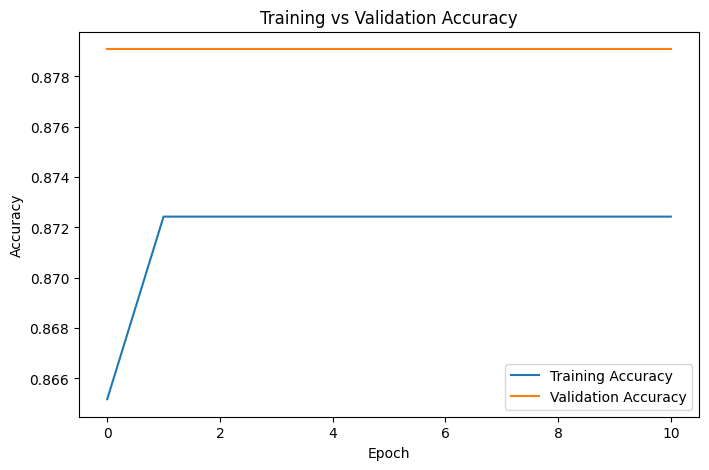

In [ ]:
# STEP 18: Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.show()

In [ ]:
# STEP 19: Predict New SMS
new_sms = input("Enter your SMS: ")

# Text sequence
new_sms_seq = tokenizer.texts_to_sequences([new_sms])

# Sequence same length
new_sms_pad = pad_sequences(new_sms_seq,maxlen=MAX_LEN,padding='post',truncating='post')

# Prediction
prediction = model.predict(new_sms_pad)

# Probability class convert
if prediction[0][0] >= 0.5:
    print("\nPrediction: SPAM")
    print("Spam Probability:", float(prediction[0][0]))
else:
    print("\nPrediction: correct information")
    print("Spam Probability:", float(prediction[0][0]))

Enter your SMS: Dear Students,                                        please go through this infographic on Forward Deployed Engineer (FDE) to understand this emerging career opportunity, the skills required, and how you can prepare for it.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Prediction: correct information
Spam Probability: 0.12103886902332306
